In this notebook, we will be creating a CNN (Convolutional Neural Network) based classifier for the classification of CIFAR-10 dataset.

**About the dataset**

CIFAR-10 dataset is a subset of CIFAR-100 having 80 million images of 100 different objects. CIFAR-10 takes 60,000 images for 10 classes from the original dataset in which 50,000 images are for training and 10,000 images are for testing.

The classes in the dataset are -
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


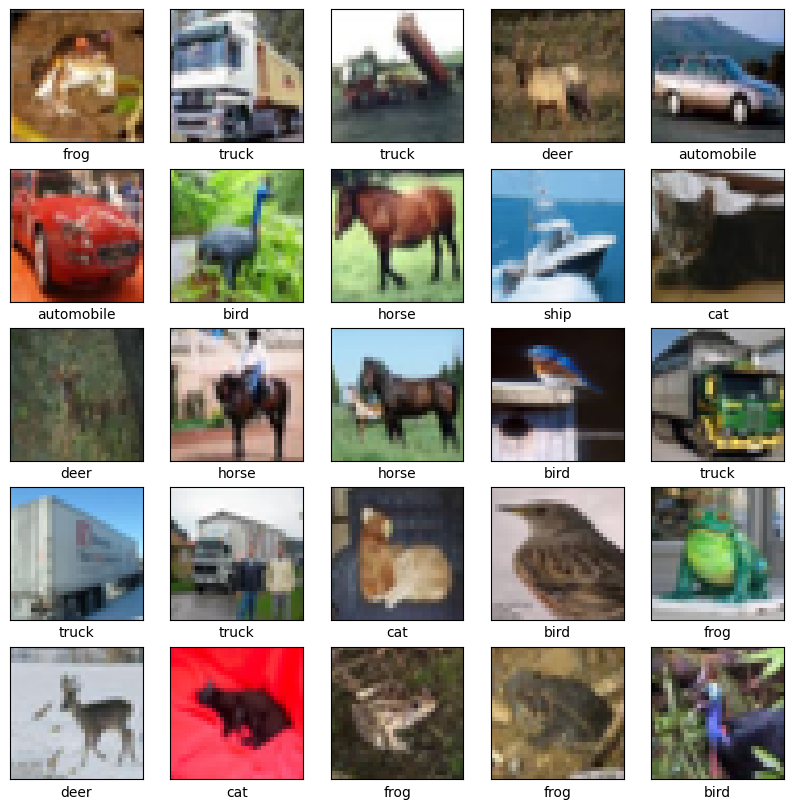

In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Creating a CNN model**

We are going to create a CNN based classification model using *keras* module.

In [3]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer='sgd',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=15,validation_data=(test_images, test_labels))


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.2416 - loss: 2.0494 - val_accuracy: 0.3338 - val_loss: 1.8001
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.3999 - loss: 1.6487 - val_accuracy: 0.4002 - val_loss: 1.6587
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.4712 - loss: 1.4625 - val_accuracy: 0.4920 - val_loss: 1.3971
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.5156 - loss: 1.3522 - val_accuracy: 0.5275 - val_loss: 1.3058
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.5497 - loss: 1.2662 - val_accuracy: 0.5512 - val_loss: 1.2509
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.5783 - loss: 1.1945 - val_accuracy: 0.5687 - val_loss: 1.2055
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.6013 - loss: 1.1311 - val_accuracy: 0.5808 - val_loss: 1.1665
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6238 -

313/313 - 5s - 16ms/step - accuracy: 0.6370 - loss: 1.0721


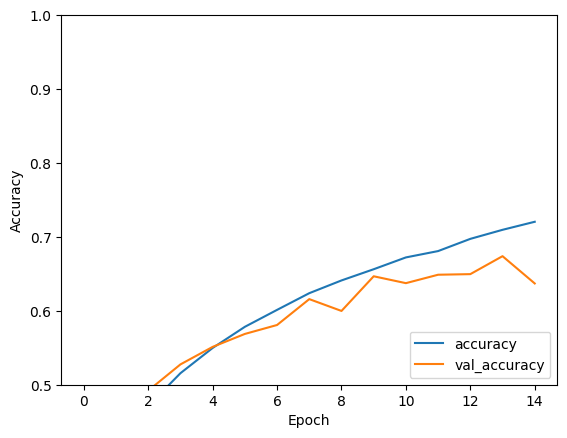

In [6]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [7]:
print(test_acc)

0.6370000243186951


In [8]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=15,validation_data=(test_images, test_labels))

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.6736 - loss: 0.9313 - val_accuracy: 0.6668 - val_loss: 0.9651
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7071 - loss: 0.8347 - val_accuracy: 0.6744 - val_loss: 0.9384
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.7394 - loss: 0.7410 - val_accuracy: 0.6886 - val_loss: 0.9170
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7651 - loss: 0.6673 - val_accuracy: 0.6953 - val_loss: 0.9018
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.7889 - loss: 0.5998 - val_accuracy: 0.7043 - val_loss: 0.9076
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.8116 - loss: 0.5371 - val_accuracy: 0.6856 - val_loss: 0.9659
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.8298 - loss: 0.4828 - val_accuracy: 0.6917 - val_loss: 0.9990
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.8458 -

313/313 - 4s - 14ms/step - accuracy: 0.6937 - loss: 1.4858


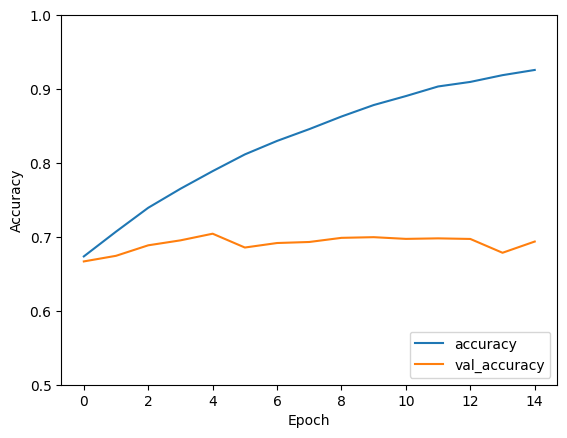

In [9]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [10]:
print(test_acc)

0.6937000155448914


In [11]:
# save model
model.save('final_model.keras') #previously saved as 'final_model.h5", a legacy

In [15]:
# ================= PREDICT + SHOW IMAGE =================
import matplotlib.pyplot as plt

def predict_image(img_path):
    if not os.path.exists(img_path):
        print(f"ERROR: {img_path} not found")
        return

    # Load image
    img = image.load_img(img_path, target_size=(32,32))
    img_array = image.img_to_array(img) / 255.0
    img_array_expanded = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array_expanded)
    class_index = np.argmax(prediction)
    label = class_names[class_index]

    # Show image
    plt.imshow(img_array)
    plt.title(f"Prediction: {label}")
    plt.axis('off')
    plt.show()

    print(f"{img_path} -> {label}")

In [16]:
def predict_with_loaded_model(img_path):
    if not os.path.exists(img_path):
        print(f"ERROR: {img_path} not found")
        return

    img = image.load_img(img_path, target_size=(32,32))
    img_array = image.img_to_array(img) / 255.0
    img_array_expanded = np.expand_dims(img_array, axis=0)

    prediction = loaded_model.predict(img_array_expanded)
    class_index = np.argmax(prediction)
    label = class_names[class_index]

    plt.imshow(img_array)
    plt.title(f"(Loaded Model) Prediction: {label}")
    plt.axis('off')
    plt.show()

    print(f"{img_path} -> {label}")

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    if not os.path.exists(img_path):
        print(f"ERROR: {img_path} not found")
        return

    img = image.load_img(img_path, target_size=(32,32))
    img_array = image.img_to_array(img) / 255.0
    img_array_expanded = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array_expanded)[0]

    class_index = np.argmax(prediction)
    label = class_names[class_index]

    plt.imshow(img_array)
    plt.title(f"Prediction: {label}")
    plt.axis('off')
    plt.show()

    print(f"{img_path} -> {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


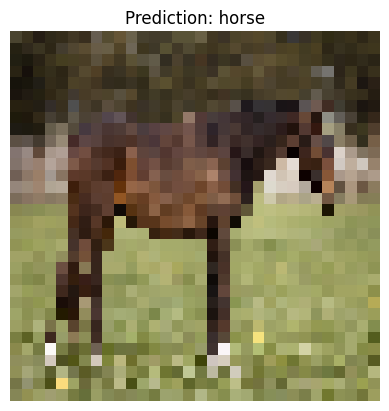

horse.jpg -> horse
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


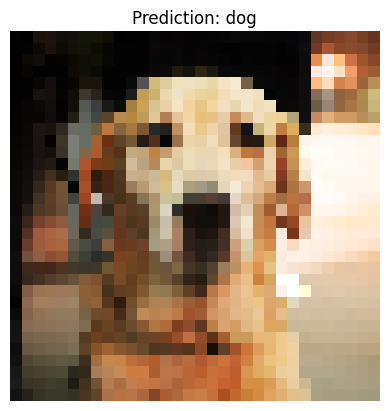

dog.jpg -> dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


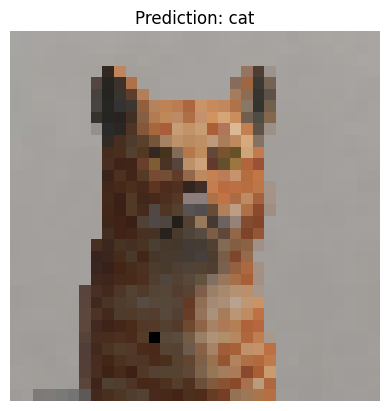

webots_capture.png -> cat


In [24]:
predict_image("horse.jpg")
predict_image("dog.jpg")
predict_image("webots_capture.png")